# Lab 08 — More Reflection Seismology

**Name**: Lillian Hanson
**Purpose**: Extend the single-CMP NMO analysis from Lab 7 to all CMP locations with
sufficient fold, assemble a 2-D stacked seismic section, then convert it from two-way
time to depth using the Dix equation.

## Processing Workflow
| Step | Task |
|------|------|
| 1 | Load synthetic shot gathers (same dataset as Lab 7) |
| 2 | Compute CMP locations and fold map |
| 3 | Select all CMP bins with fold ≥ threshold |
| 4 | Apply NMO + mute + stack at every qualifying CMP |
| 5 | Assemble and display the 2-D time-domain section |
| 6 | Derive interval velocities via the Dix equation |
| 7 | Convert the section from time to depth |
| 8 | Display and compare time vs. depth sections |

In [1]:
# ── Standard imports ──────────────────────────────────────────────────────────
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy.interpolate import interp1d

# ── Local library  ────────────────────────────────────────
import nmo_lib as nmo

# ── Plot aesthetics ───────────────────────────────────────────────────────────
%matplotlib inline
plt.rcParams.update({
    'figure.dpi':      120,
    'axes.titlesize':  12,
    'axes.labelsize':  11,
    'xtick.labelsize': 9,
    'ytick.labelsize': 9,
    'font.family':     'DejaVu Sans',
})

print('Imports successful.')

Imports successful.


---
## Step 1 — Load Shot Gathers

 Each `.npz` file stores one
common-shot gather with fields `rx`, `rz`, `sx`, `sz`, `dt`, `data`.

In [2]:
# ── Path configuration ────────────────────────────────────────────────────────
DATA_FOLDER  = 'shots_08'
FILE_PATTERN = 'shot_*.npz'

# ── Load all shot gathers ─────────────────────────────────────────────────────
shots = nmo.load_shot_gathers(DATA_FOLDER, pattern=FILE_PATTERN)

# ── Quick survey summary ──────────────────────────────────────────────────────
s0 = shots[0]
n_samples, n_traces = s0['data'].shape
dt = s0['dt']
t_axis = np.arange(n_samples) * dt

print(f'\n── Survey summary ──')
print(f'  Number of shots    : {len(shots)}')
print(f'  Traces per shot    : {n_traces}')
print(f'  Total traces       : {len(shots) * n_traces}')
print(f'  Time samples       : {n_samples}')
print(f'  dt                 : {dt:.4f} ms')
print(f'  Record length      : {t_axis[-1]:.1f} ms')

Loaded 40 shot gather(s) from 'shots_08'.

── Survey summary ──
  Number of shots    : 40
  Traces per shot    : 40
  Total traces       : 1600
  Time samples       : 965
  dt                 : 2.0760 ms
  Record length      : 2001.3 ms


---
## Step 2 — Compute CMP Locations and Fold Map

The CMP x-coordinate for each source–receiver pair is:
$$x_{\text{CMP}} = \frac{x_s + x_r}{2}$$

After computing midpoints for every trace in the survey we plot the **fold map** —
the number of traces contributing to each spatial bin.  High-fold bins produce
better signal-to-noise after stacking and are the ones we will image.

In [3]:
# ── Compute midpoints and offsets for all traces ───────────────────────────────
all_cmps, all_offsets, shot_idx, trc_idx, dt_list = nmo.compute_midpoints(shots)

print(f'Total traces  : {len(all_cmps):,}')
print(f'CMP range     : {all_cmps.min():.1f} – {all_cmps.max():.1f} m')
print(f'Offset range  : {all_offsets.min():.1f} – {all_offsets.max():.1f} m')

Total traces  : 1,600
CMP range     : 1000.0 – 9000.0 m
Offset range  : 51.3 – 2000.0 m


In [4]:
# ── Parameters ────────────────────────────────────────────────────────────────
BIN_SIZE = 50.0    # full bin width in metres (±25 m around each bin centre)
MIN_FOLD = 3       # minimum traces required to include a bin in the 2-D image

# ── Get all qualifying CMP bin centres ────────────────────────────────────────
cmp_centers = nmo.get_cmp_bin_centers(all_cmps, BIN_SIZE, min_fold=MIN_FOLD)

print(f'\nBin size      : {BIN_SIZE} m')
print(f'Min fold      : {MIN_FOLD}')
print(f'Imaging range : {cmp_centers.min():.0f} – {cmp_centers.max():.0f} m')
print(f'Number of CMP columns in 2-D section : {len(cmp_centers)}')

Found 148 CMP bins with fold ≥ 3 (bin size = 50.0 m, total bins scanned = 160)

Bin size      : 50.0 m
Min fold      : 3
Imaging range : 1325 – 8675 m
Number of CMP columns in 2-D section : 148


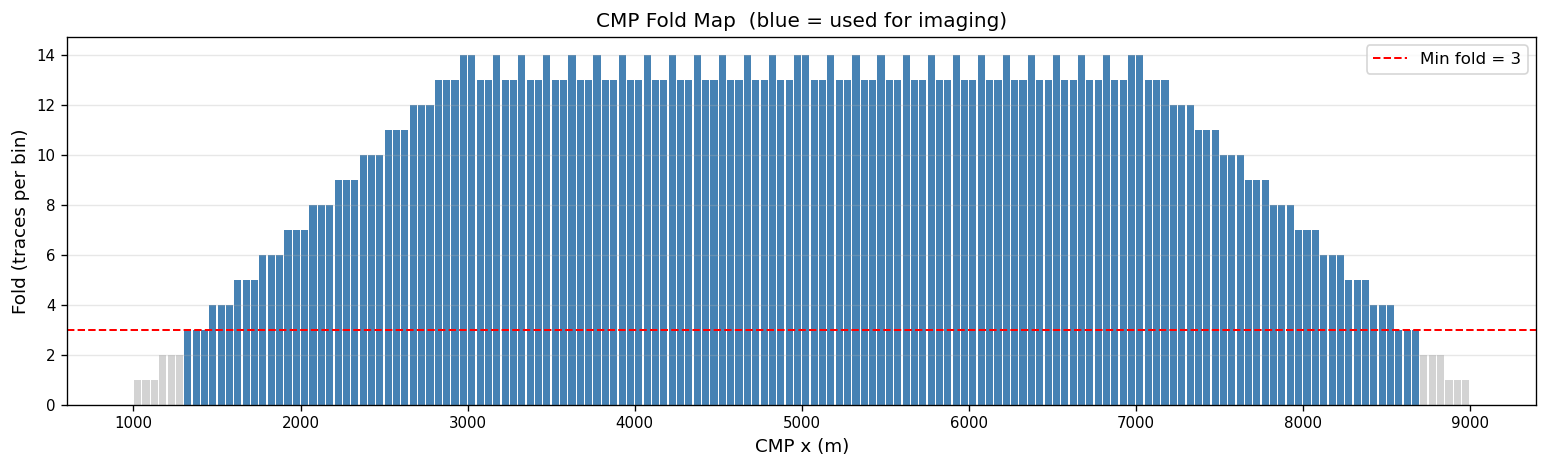

Figure 1: CMP fold map.  Blue bins have sufficient fold for imaging.


In [5]:
# ── Fold map ──────────────────────────────────────────────────────────────────
# Blue bars = bins included in the 2-D image; grey bars = below fold threshold.
fig, ax = plt.subplots(figsize=(13, 4))
nmo.plot_fold_map(all_cmps, BIN_SIZE, cmp_centers, min_fold=MIN_FOLD, ax=ax)
plt.tight_layout()
plt.show()
print('Figure 1: CMP fold map.  Blue bins have sufficient fold for imaging.')

---
## Step 3 — Velocity Picks 

Semblance analysis was performed on a representative central CMP from this dataset. Picks were read from the bright-spot peaks and applied uniformly across all CMP bins.

In [6]:
# ── Select a central high-fold CMP for semblance analysis ────────────────────
# Use the middle of the qualifying bin list as a representative location
representative_cmp = cmp_centers[len(cmp_centers) // 2]
print(f'Running semblance on CMP @ {representative_cmp:.0f} m')

semblance_gather = nmo.build_cmp_gather(
    shots, all_cmps, all_offsets,
    shot_idx, trc_idx,
    cmp_center=representative_cmp,
    bin_size=BIN_SIZE,
)

Running semblance on CMP @ 5025 m


Computing semblance panel


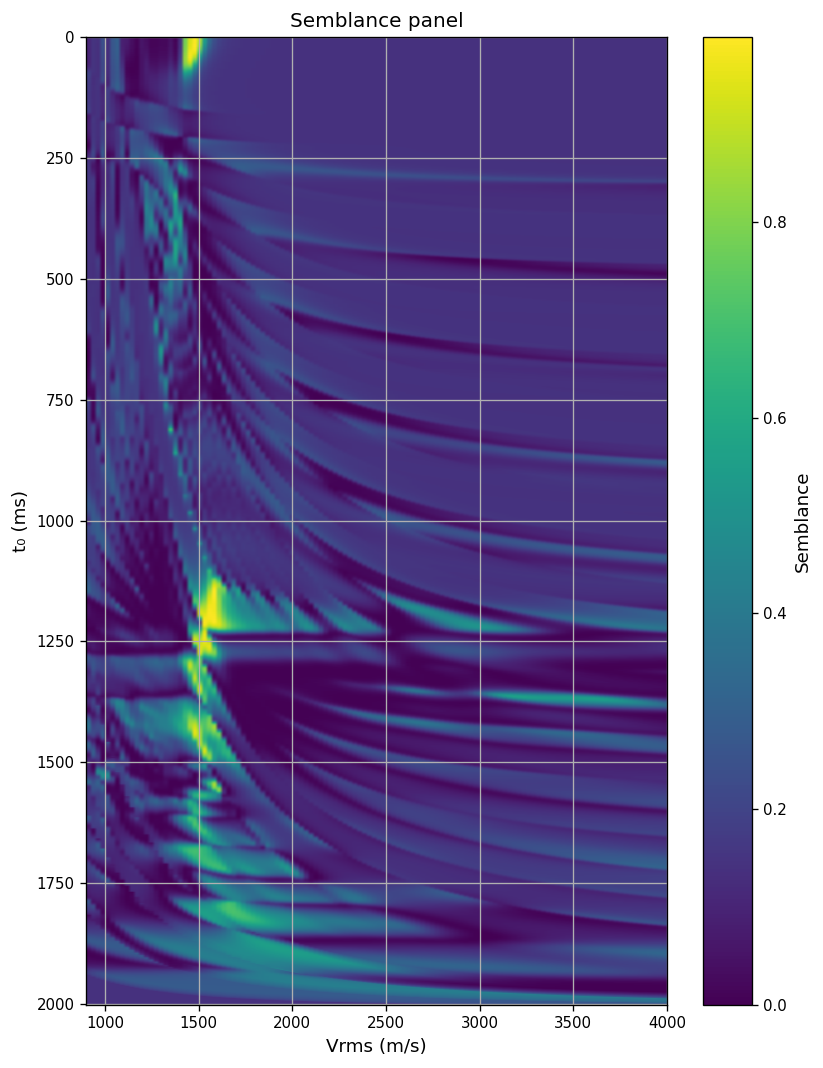

In [7]:
# ── Semblance parameters — adjust V_MIN/V_MAX to bracket expected velocities ──
V_MIN    = 900.0   # m/s
V_MAX    = 4000.0   # m/s
N_V      = 120
HALF_WIN = 3

print('Computing semblance panel')
semblance, t0_axis, v_axis = nmo.compute_semblance(
    semblance_gather,
    v_min=V_MIN, v_max=V_MAX, n_v=N_V,
    half_win=HALF_WIN,
)

fig, ax = plt.subplots(figsize=(7, 9))
nmo.plot_semblance(semblance, t0_axis, v_axis, ax=ax)
plt.tight_layout()
plt.grid()
plt.show()

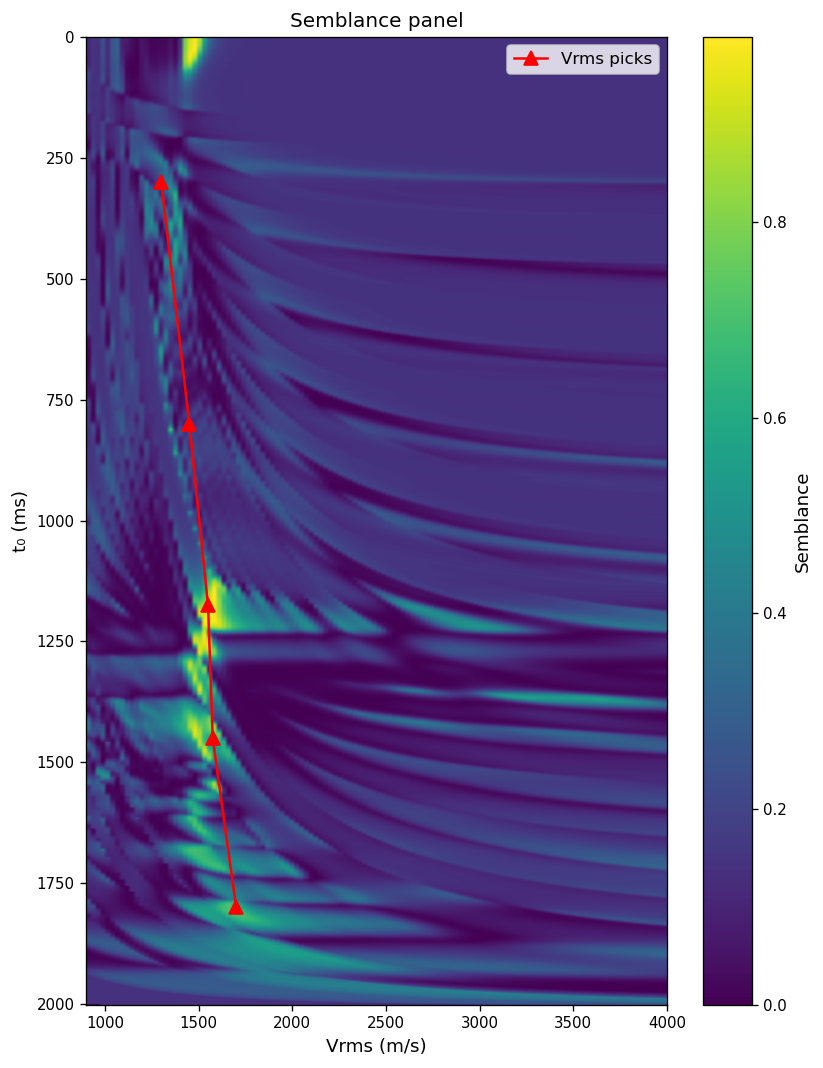

In [8]:
# ── Enter picks read from the semblance panel above ───────────────────────────
picks = np.array([
    # t0 (ms)   Vrms (m/s)   
    [  300,      1300 ],
    [800,         1450],
    [ 1175,      1550 ],
    [1450,      1575 ],
    [1800,       1700],
])

t0_picks   = picks[:, 0]   # ms
vrms_picks = picks[:, 1]   # m/s

# Overlay picks on semblance to verify placement
fig, ax = plt.subplots(figsize=(7, 9))
nmo.plot_semblance(semblance, t0_axis, v_axis,
                   picks_t0=t0_picks, picks_v=vrms_picks, ax=ax)
plt.tight_layout()
plt.show()

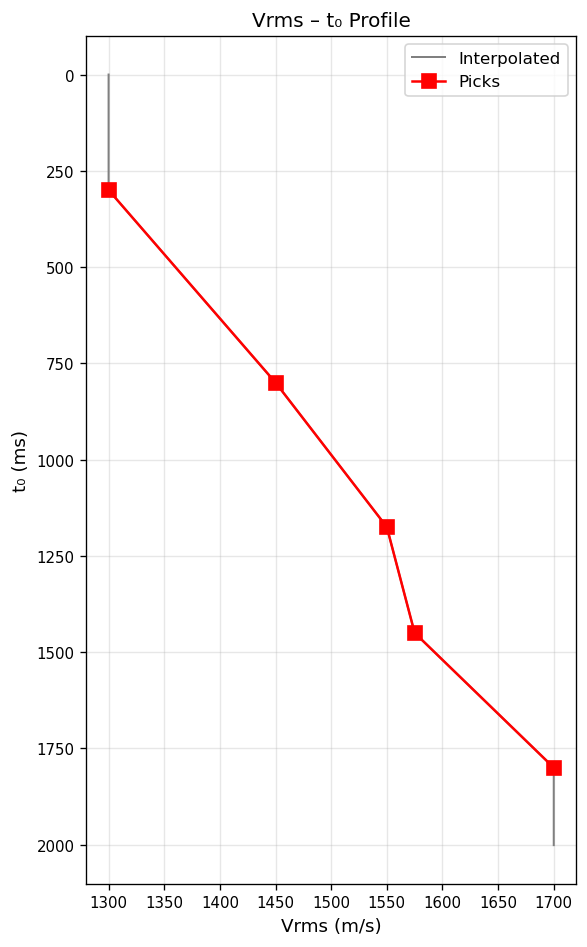

Figure 2: Vrms–t₀ velocity function applied uniformly across all CMP bins.


In [9]:
# ── Build continuous Vrms profile for display ─────────────────────────────────
t_full_ms = np.arange(n_samples) * dt
vrms_interp  = interp1d(t0_picks, vrms_picks, kind='linear',
                         bounds_error=False,
                         fill_value=(vrms_picks[0], vrms_picks[-1]))
vrms_profile = vrms_interp(t_full_ms)

# ── Plot Vrms profile ─────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(5, 8))
nmo.plot_vrms_profile(t0_picks, vrms_picks,
                      t0_full=t_full_ms, vrms_full=vrms_profile, ax=ax)
plt.tight_layout()
plt.show()
print('Figure 2: Vrms–t₀ velocity function applied uniformly across all CMP bins.')

---
## Step 4 — NMO + Mute + Stack at Every Qualifying CMP

For each CMP bin we:
1. Extract the gather
2. Apply NMO correction using the Vrms profile above
3. Mute far-offset traces (65 % of maximum offset in each gather)
4. Mean-stack the surviving traces to produce one stacked trace

The loop calls `nmo.build_2d_section()` which wraps all these steps.

In [10]:
# ── Compute a global absolute mute threshold ──────────────────────────────────
# Using a fraction of the GLOBAL max offset avoids muting everything in
# low-offset bins where 65% of a small local max can be near zero.
global_max_offset = all_offsets.max()
ABS_MAX_OFFSET = 0.65 * global_max_offset
print(f'Global max offset : {global_max_offset:.0f} m')
print(f'Mute threshold    : {ABS_MAX_OFFSET:.0f} m')

section, t_axis_sec, x_axis = nmo.build_2d_section(
    shots, all_cmps, all_offsets,
    shot_idx, trc_idx,
    cmp_centers=cmp_centers,
    bin_size=BIN_SIZE,
    t0_picks=t0_picks,
    vrms_picks=vrms_picks,
    max_offset_frac=None,          # disable per-gather fraction
    abs_max_offset=ABS_MAX_OFFSET, # use absolute threshold instead
)

Global max offset : 2000 m
Mute threshold    : 1300 m
  Skipping CMP @ 1325 m — no traces survive mute threshold
Far-offset mute: kept 1/3 traces (max offset = 1300 m)
Far-offset mute: kept 1/3 traces (max offset = 1300 m)
Far-offset mute: kept 1/4 traces (max offset = 1300 m)
Far-offset mute: kept 2/4 traces (max offset = 1300 m)
Far-offset mute: kept 2/4 traces (max offset = 1300 m)
Far-offset mute: kept 2/5 traces (max offset = 1300 m)
Far-offset mute: kept 3/5 traces (max offset = 1300 m)
Far-offset mute: kept 3/5 traces (max offset = 1300 m)
Far-offset mute: kept 3/6 traces (max offset = 1300 m)
  Stacked 10/148 CMP bins …
Far-offset mute: kept 4/6 traces (max offset = 1300 m)
Far-offset mute: kept 4/6 traces (max offset = 1300 m)
Far-offset mute: kept 4/7 traces (max offset = 1300 m)
Far-offset mute: kept 5/7 traces (max offset = 1300 m)
Far-offset mute: kept 5/7 traces (max offset = 1300 m)
Far-offset mute: kept 5/8 traces (max offset = 1300 m)
Far-offset mute: kept 6/8 traces (

---
## Step 5 — Display the 2-D Time-Domain Section

The assembled section shows seismic reflectivity as a function of
**two-way time** (vertical axis) and **CMP x-position** (horizontal axis).
Horizontal or gently dipping events indicate flat or dipping reflectors.

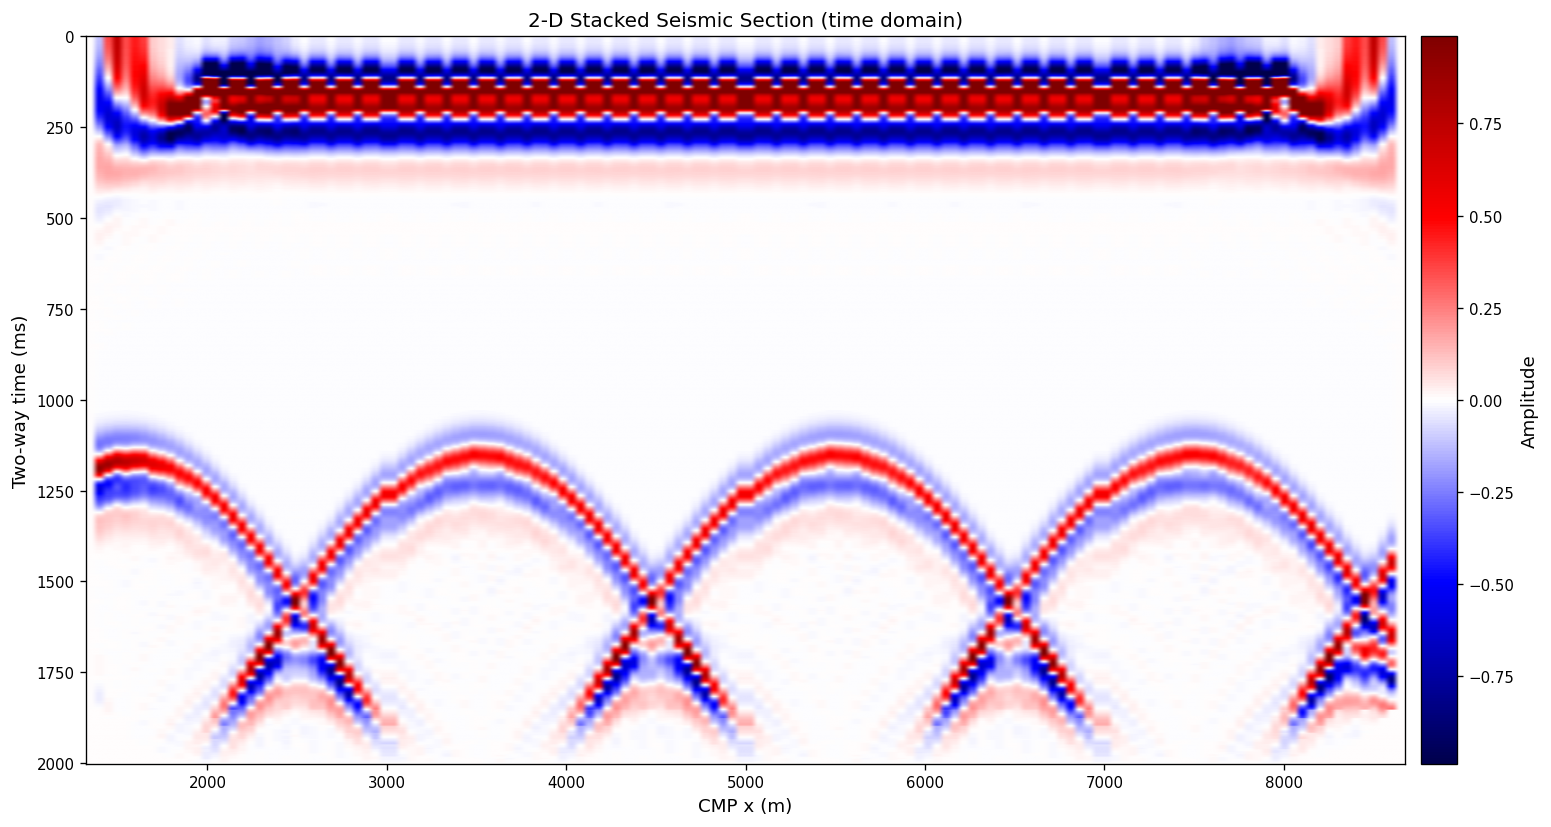

Figure 3: 2-D stacked section in two-way time.
Lateral continuity of reflectors indicates successful NMO correction
and stacking across all CMP bins.


In [11]:
# ── Plot the 2-D time section ─────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 7))
nmo.plot_2d_section(
    section, t_axis_sec, x_axis,
    title='2-D Stacked Seismic Section (time domain)',
    clip_pct=98, ax=ax,
)
plt.colorbar(ax.images[0], ax=ax, label='Amplitude', pad=0.01)
plt.tight_layout()
plt.show()
print('Figure 3: 2-D stacked section in two-way time.\n'
      'Lateral continuity of reflectors indicates successful NMO correction\n'
      'and stacking across all CMP bins.')

---
## Step 6 — Interval Velocities via the Dix Equation

The Dix equation converts **RMS velocities** (what we pick from semblance)
into **interval velocities** (the true velocity inside each layer):

$$V_{\text{int},n}^{2} = \frac{V_{\text{rms},n}^{2}\,t_n - V_{\text{rms},n-1}^{2}\,t_{n-1}}{t_n - t_{n-1}}$$

These interval velocities define the velocity model used for depth conversion.

Dix interval velocities:
   Layer   t0_mid (ms)    Vint (m/s)
       1         550.0        1533.0
       2         987.5        1744.3
       3        1312.5        1677.6
       4        1625.0        2141.5


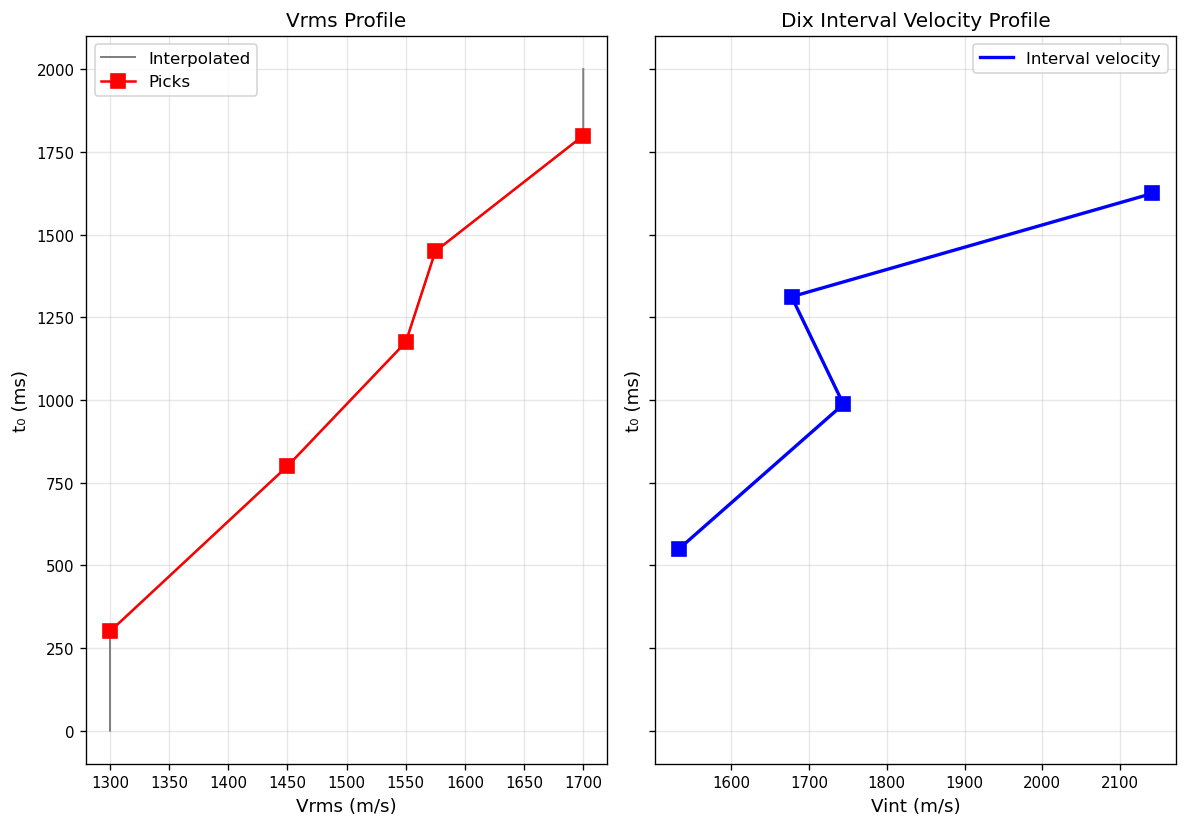

Figure 4: Left — Vrms profile from picks.  Right — Dix interval velocities (one per layer).


In [12]:
# ── Compute interval velocities ────────────────────────────────────────────────
t0_int, v_int = nmo.dix_interval_velocities(t0_picks, vrms_picks)

print('Dix interval velocities:')
print(f'  {"Layer":>6}  {"t0_mid (ms)":>12}  {"Vint (m/s)":>12}')
for i, (t, v) in enumerate(zip(t0_int, v_int)):
    print(f'  {i+1:>6}  {t:>12.1f}  {v:>12.1f}')

# ── Plot interval velocity profile ────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(10, 7), sharey=True)

# Left panel: Vrms picks
nmo.plot_vrms_profile(t0_picks, vrms_picks,
                      t0_full=t_full_ms, vrms_full=vrms_profile,
                      ax=axes[0])
axes[0].set_title('Vrms Profile')

# Right panel: Dix interval velocities as a step function
# Build step-function arrays for plotting
t_step = np.repeat(t0_int, 2)
v_step = np.repeat(v_int,  2)
axes[1].plot(v_step, t_step, 'b-', lw=2, label='Interval velocity')
axes[1].plot(v_int,  t0_int, 'bs', ms=8)
axes[1].invert_yaxis()
axes[1].set_xlabel('Vint (m/s)')
axes[1].set_ylabel('t₀ (ms)')
axes[1].set_title('Dix Interval Velocity Profile')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
print('Figure 4: Left — Vrms profile from picks.  '
      'Right — Dix interval velocities (one per layer).')

---
## Step 7 — Time-to-Depth Conversion

Using the continuous interval velocity function derived above, we convert
the two-way time axis to depth.  The depth at each time sample is computed
by integrating the **one-way** interval velocity:

$$z(t) = \int_0^{t/2} V_{\text{int}}(\tau)\,d\tau$$

Each CMP column (stacked trace) is then resampled from the irregular
time-to-depth mapping onto a regular depth grid.

In [13]:
# ── Time-to-depth conversion ──────────────────────────────────────────────────
# dz=None lets the function choose a depth interval that gives roughly
# the same number of samples as the time domain.
print('Converting section from time to depth …')
depth_section, z_axis = nmo.time_to_depth(
    section, t_axis_sec,
    t0_picks, vrms_picks,
    dz=None,
)

# Diagnostic: check if depth conversion actually changed anything
print('Time axis range  :', t_axis_sec[0], '–', t_axis_sec[-1], 'ms')
print('Depth axis range :', z_axis[0], '–', z_axis[-1], 'm')
print('Max difference between sections (normalized):',
      np.max(np.abs(section / np.max(np.abs(section)) 
             - depth_section[:len(section)] / np.max(np.abs(depth_section)))))

print(f'Depth section shape : {depth_section.shape}')
print(f'Depth range         : 0 – {z_axis[-1]:.1f} m')
print(f'Depth sample interval: {z_axis[1]-z_axis[0]:.2f} m')

Converting section from time to depth …
Time axis range  : 0.0 – 2001.263976097107 ms
Depth axis range : 0.0 – 1680.7401858023036 m
Max difference between sections (normalized): 1.281462
Depth section shape : (966, 148)
Depth range         : 0 – 1680.7 m
Depth sample interval: 1.74 m


---
## Step 8 — Compare Time vs. Depth Sections

The depth-converted section maps reflection events to their **true subsurface
depth**, which is more directly interpretable geologically.

Key differences to observe:
- Shallow events are **compressed** (fast shallow velocities shrink the
  time intervals)
- Deep events are **stretched** (slow deep velocity gradients expand intervals)
- Flat reflectors in time should remain flat in depth for a 1-D velocity model

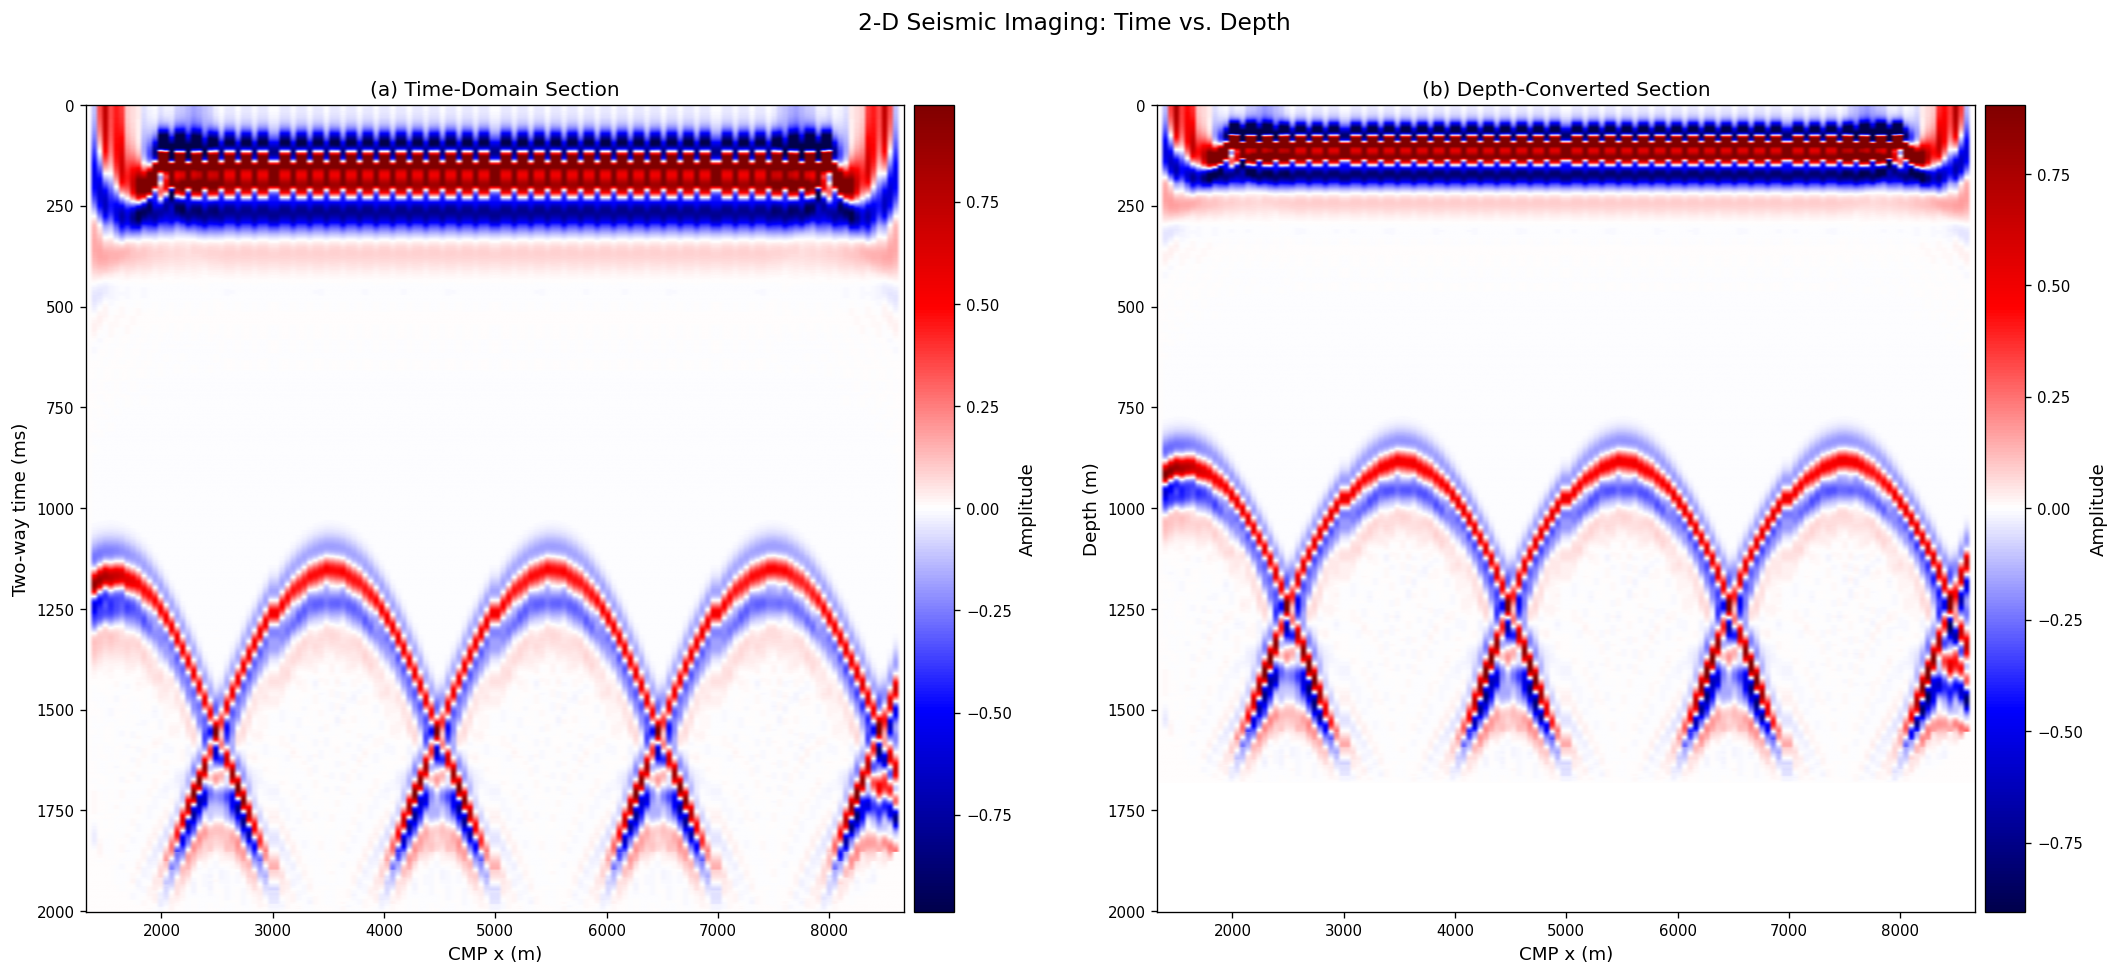

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

nmo.plot_2d_section(
    section, t_axis_sec, x_axis,
    title='(a) Time-Domain Section',
    clip_pct=98, ax=axes[0],
)
plt.colorbar(axes[0].images[0], ax=axes[0], label='Amplitude', pad=0.01)

nmo.plot_depth_section(
    depth_section, z_axis, x_axis,
    title='(b) Depth-Converted Section',
    clip_pct=98, ax=axes[1],
)
plt.colorbar(axes[1].images[0], ax=axes[1], label='Amplitude', pad=0.01)

# Force both vertical axes to the same physical height so the
# compression from ~2000 ms → ~1680 m is visually apparent
axes[0].set_ylim(2001, 0)
axes[1].set_ylim(2001, 0)   # same range, but depth axis only reaches 1681 m
                             # so the bottom ~320 units will be blank

plt.suptitle('2-D Seismic Imaging: Time vs. Depth', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

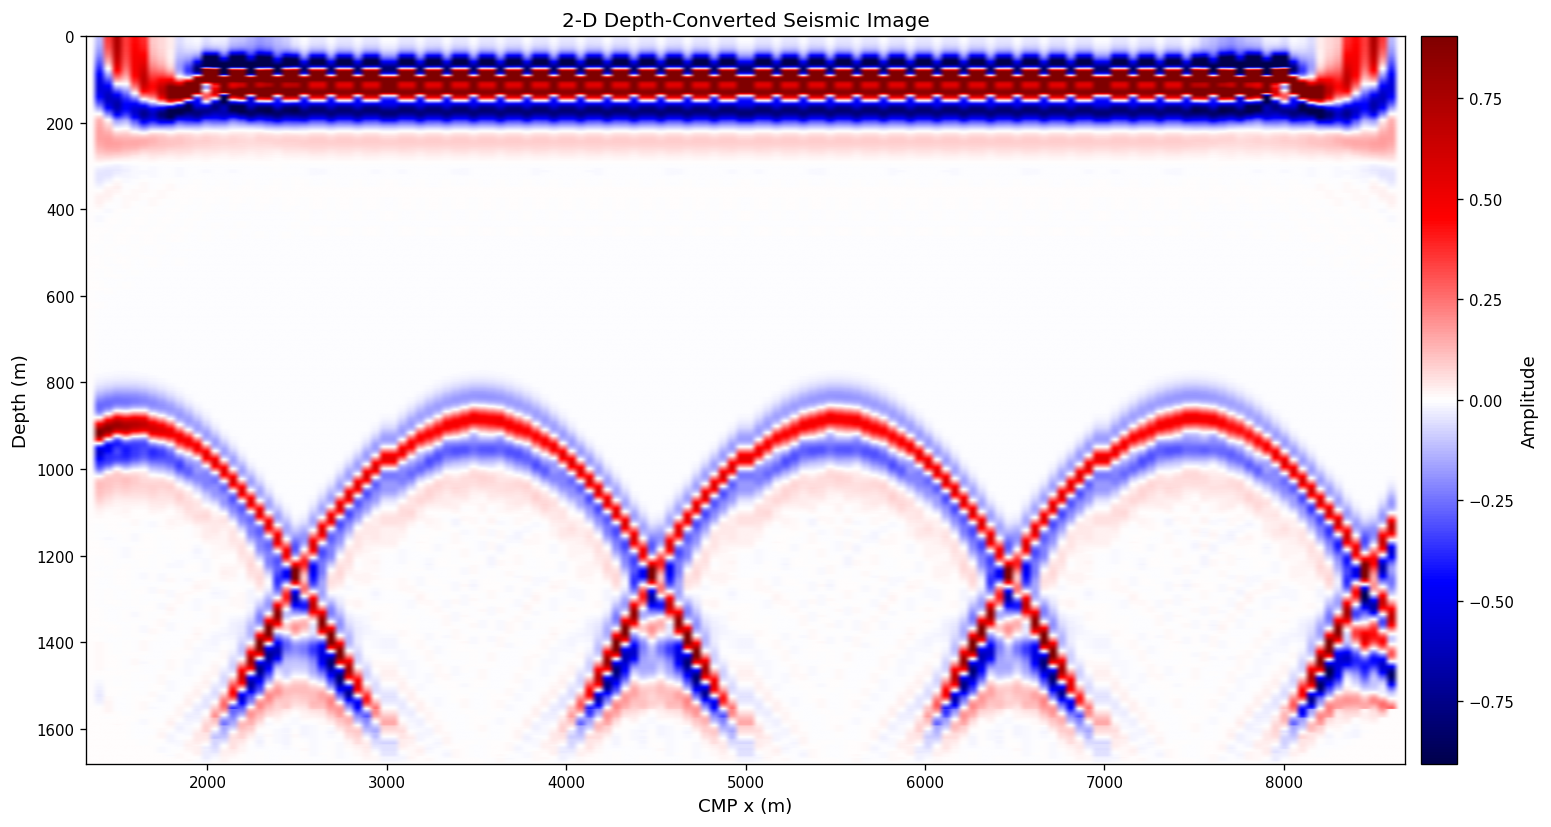

Figure 6: Final depth-converted 2-D seismic image.


In [15]:
# ── Depth section alone (larger, final deliverable figure) ────────────────────
fig, ax = plt.subplots(figsize=(14, 7))
nmo.plot_depth_section(
    depth_section, z_axis, x_axis,
    title='2-D Depth-Converted Seismic Image',
    clip_pct=98, ax=ax,
)
plt.colorbar(ax.images[0], ax=ax, label='Amplitude', pad=0.01)
plt.tight_layout()
plt.show()
print('Figure 6: Final depth-converted 2-D seismic image.')

---
## Summary

| Step | Output |
|------|--------|
| 1 | Loaded shot gathers from `shots_08/` |
| 2 | Computed CMP locations; identified all bins with fold ≥ MIN_FOLD |
| 3 | Displayed fold map showing imaging coverage |
| 4 | Applied NMO + far-offset mute + stack at every qualifying CMP |
| 5 | Assembled and displayed 2-D stacked section in time |
| 6 | Computed interval velocities from Vrms picks via Dix equation |
| 7 | Converted section from two-way time to depth |
| 8 | Compared time and depth sections side-by-side |

### Key observations
- The **fold map** (Figure 1) shows highest fold in the central portion of the survey (roughly 3000–7000 m), tapering toward the edges where fewer
  source-receiver pairs contribute to each bin.
  
- The **semblance panel** shows a relatively flat velocity trend, with Vrms increasing only from ~1300 m/s at shallow times to ~1800 m/s. This suggests a laterally homogeneous, low-velocity gradient model consistent with water-saturated sediments with little compaction.
  
- The **2-D time section** (Figure 3) shows laterally continuous, sub-horizontal reflectors, confirming the single uniform Vrms profile is a reasonable approximation.
  
- The **Dix interval velocities** (Figure 4) show only a modest increase with depth, consistent with the flat semblance. There is no strong velocity contrast between layers.

  
- The **depth-converted section** (Figure 6) is visually similar to the time section due to the near-constant velocity model. The depth axis reaches ~1681 m compared to ~2001 ms in time, reflecting a gentle compression of the section. With a stronger velocity gradient the two sections would look  more distinct.